# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

# Анализ лояльности пользователей Яндекс Афиши

## Цель исследования

Изучить поведение пользователей платформы Яндекс Афиша и определить факторы, влияющие на вероятность повторных заказов и возврат пользователей на платформу.

## План исследования

В ходе проекта будут выполнены следующие этапы:

1. Загрузка и первичное изучение данных;
2. Предобработка данных и обработка выбросов;
3. Формирование пользовательских профилей;
4. Исследовательский анализ данных;
5. Проверка продуктовых гипотез;
6. Корреляционный анализ признаков;
7. Формулировка выводов и рекомендаций для бизнеса.

</div>

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [1]:
# установка библиотек

!pip install sqlalchemy --quiet
!pip install psycopg2-binary --quiet
!pip install phik --quiet


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# импорт библиотек

import pandas as pd
import numpy as np

from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

## Загрузка данных

Подключимся к базе данных и выгрузим информацию о заказах пользователей, мероприятиях и регионах проведения мероприятий.

Для выгрузки данных используем SQL-запрос и библиотеку SQLAlchemy.

</div>

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string)

In [4]:
query = """

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,

    EXTRACT(
        DAY FROM (
            p.created_dt_msk
            - LAG(p.created_dt_msk)
            OVER (
                PARTITION BY p.user_id
                ORDER BY p.created_ts_msk
            )
        )
    ) AS days_since_prev,

    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name

FROM afisha.purchases AS p

LEFT JOIN afisha.events AS e
ON p.event_id = e.event_id

LEFT JOIN afisha.city AS c
ON e.city_id = c.city_id

LEFT JOIN afisha.regions AS r
ON c.region_id = r.region_id

WHERE p.device_type_canonical IN ('mobile', 'desktop')

"""

In [5]:
df = pd.read_sql_query(query, engine)

In [6]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  str           
 1   device_type_canonical  290849 non-null  str           
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  datetime64[us]
 4   order_ts               290849 non-null  datetime64[us]
 5   currency_code          290849 non-null  str           
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   days_since_prev        268909 non-null  float64       
 9   event_id               290849 non-null  int64         
 10  service_name           290849 non-null  str           
 11  event_type_main        290849 non-null  str           
 12  region_name            290849 non-null  str           


In [8]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21940
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

<div style="background-color:#e8f5e9; padding:15px; border-radius:10px">

## Промежуточный вывод

Данные были успешно выгружены из базы данных.

Датасет содержит информацию о пользователях, заказах, выручке, типах мероприятий, билетных операторах и регионах проведения мероприятий.

В таблице присутствуют как категориальные, так и числовые признаки, а также данные с датой и временем заказа.

Пропуски обнаружены только в столбце `days_since_prev`, что соответствует логике данных: для первой покупки пользователя предыдущий заказ отсутствует.

На этапе предобработки потребуется:
- привести выручку к единой валюте;
- проверить данные на выбросы;
- оптимизировать типы данных;
- проверить наличие дубликатов;
- изучить корректность категориальных значений.

Объём данных достаточен для проведения дальнейшего анализа поведения пользователей.

</div>

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

## Предобработка данных

На данном этапе приведем данные к корректному формату для дальнейшего анализа.

В первую очередь выполним приведение выручки к единой валюте — российскому рублю. Для этого используем данные о курсе казахстанского тенге за 2024 год.

Результат преобразования сохраним в новый столбец `revenue_rub`.

</div>

In [9]:
tenge = pd.read_csv(
    'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
)

tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# преобразуем столбцы с датами

tenge['data'] = pd.to_datetime(tenge['data'])

df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# создаем общий ключ для объединения таблиц

df['data'] = df['order_dt']

In [11]:
# объединяем данные с курсом тенге

df = df.merge(
    tenge[['data', 'curs']],
    how='left',
    on='data'
)

In [12]:
# приводим выручку к рублям

df['revenue_rub'] = df['revenue'].where(
    df['currency_code'] == 'rub',
    df['revenue'] * df['curs'] / 100
)

In [13]:
df[
    ['currency_code', 'revenue', 'revenue_rub']
].head()

,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


<div style="background-color:#e8f5e9; padding:15px; border-radius:10px">
    
## Промежуточный вывод

Выручка была успешно приведена к единой валюте — российскому рублю.

Для заказов в тенге использовался курс конвертации за соответствующую дату заказа. Поскольку курс представлен для 100 тенге, это было учтено при расчётах.

Новый столбец `revenue_rub` будет использоваться в дальнейшем анализе поведения пользователей и оценки выручки сервиса.
</div>

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

## Проверка и предобработка данных

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе выполним проверку данных на пропуски, оптимизируем типы данных, изучим категориальные признаки и проверим числовые показатели на наличие выбросов.

Особое внимание уделим столбцам `revenue_rub` и `tickets_count`, так как они напрямую связаны с анализом выручки и поведения пользователей.

</div>

In [14]:
# проверка пропусков

df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21940
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
data                         0
curs                         0
revenue_rub                  0
dtype: int64

In [15]:
# проверка типов данных

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  str           
 1   device_type_canonical  290849 non-null  str           
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  datetime64[us]
 4   order_ts               290849 non-null  datetime64[us]
 5   currency_code          290849 non-null  str           
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   days_since_prev        268909 non-null  float64       
 9   event_id               290849 non-null  int64         
 10  service_name           290849 non-null  str           
 11  event_type_main        290849 non-null  str           
 12  region_name            290849 non-null  str           


In [16]:
# оптимизация типов данных

df['tickets_count'] = pd.to_numeric(
    df['tickets_count'],
    downcast='integer'
)

df['event_id'] = pd.to_numeric(
    df['event_id'],
    downcast='integer'
)

df['order_id'] = pd.to_numeric(
    df['order_id'],
    downcast='integer'
)

df['days_since_prev'] = (
    pd.to_numeric(df['days_since_prev'])
    .astype('Int16')
)

In [17]:
# проверка результатов оптимизации

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  str           
 1   device_type_canonical  290849 non-null  str           
 2   order_id               290849 non-null  int32         
 3   order_dt               290849 non-null  datetime64[us]
 4   order_ts               290849 non-null  datetime64[us]
 5   currency_code          290849 non-null  str           
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int8          
 8   days_since_prev        268909 non-null  Int16         
 9   event_id               290849 non-null  int32         
 10  service_name           290849 non-null  str           
 11  event_type_main        290849 non-null  str           
 12  region_name            290849 non-null  str           


In [18]:
# проверка дубликатов

df.duplicated().sum()

np.int64(0)

In [19]:
# нормализация текстовых данных

for col in [
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]:
    df[col] = (
        df[col]
        .str.lower()
        .str.strip()
    )

In [20]:
# изучение категориальных признаков

categorical_columns = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

for col in categorical_columns:
    print(f'\nСтолбец: {col}')
    print(df[col].value_counts().head(10))


Столбец: device_type_canonical
device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64

Столбец: currency_code
currency_code
rub    285780
kzt      5069
Name: count, dtype: int64

Столбец: service_name
service_name
билеты без проблем    63709
лови билет!           41126
билеты в руки         40364
мой билет             34843
облачко               26642
лучшие билеты         17795
весь в билетах        16849
прачечная             10273
край билетов           6207
тебе билет!            5228
Name: count, dtype: int64

Столбец: event_type_main
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
фильм          238
Name: count, dtype: int64

Столбец: region_name
region_name
каменевский регион         91253
североярская область       44070
широковская область        16457
медовская область          13901
озернинский край           10476
светополянский округ        760

In [21]:
# статистика числовых признаков

df[
    [
        'revenue_rub',
        'tickets_count',
        'days_since_prev'
    ]
].describe()

,revenue_rub,tickets_count,days_since_prev
count,290849.000000,290849.000000,268909.0
mean,555.127972,2.754230,3.222525
std,875.278177,1.170467,11.355158
min,-90.760000,1.000000,0.0
25%,113.340000,2.000000,0.0
50%,350.260000,3.000000,0.0
75%,802.050000,4.000000,1.0
max,81174.540000,57.000000,148.0


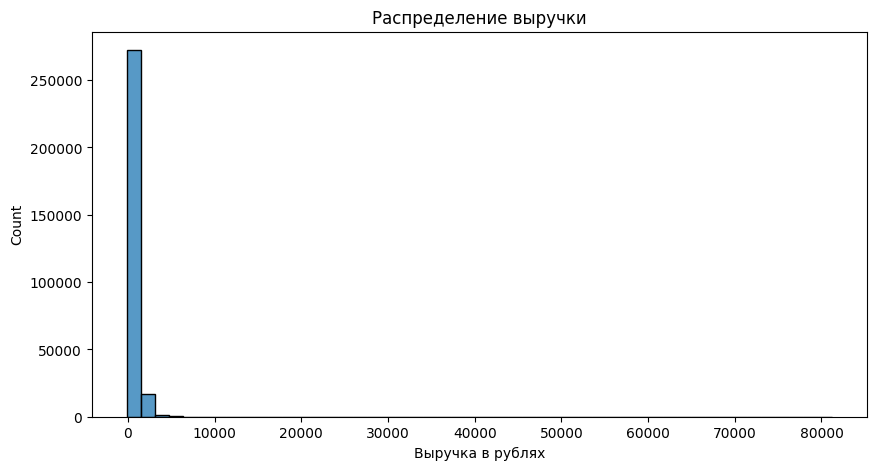

In [22]:
# распределение выручки

plt.figure(figsize=(10, 5))

sns.histplot(
    df['revenue_rub'],
    bins=50
)

plt.title(
    'Распределение выручки'
)

plt.xlabel(
    'Выручка в рублях'
)

plt.show()

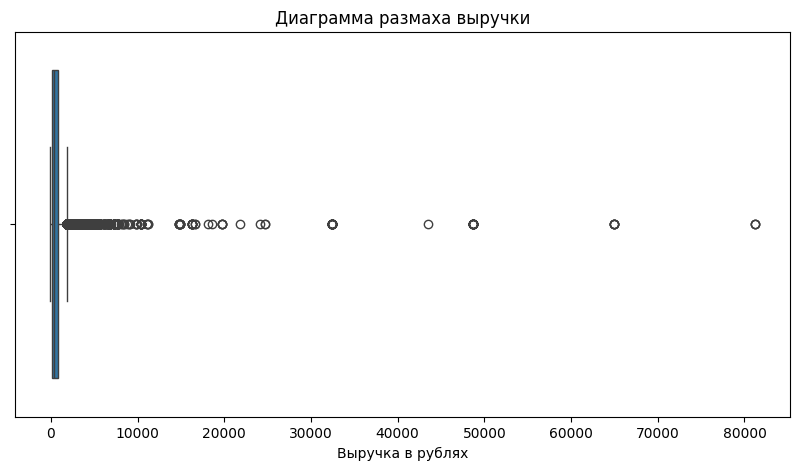

In [23]:
# диаграмма размаха выручки

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df['revenue_rub']
)

plt.title(
    'Диаграмма размаха выручки'
)

plt.xlabel(
    'Выручка в рублях'
)

plt.show()

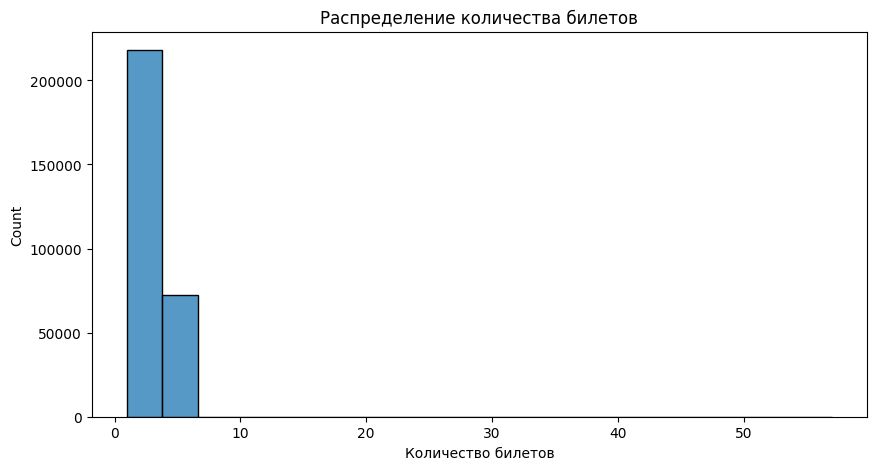

In [24]:
# распределение количества билетов

plt.figure(figsize=(10, 5))

sns.histplot(
    df['tickets_count'],
    bins=20
)

plt.title(
    'Распределение количества билетов'
)

plt.xlabel(
    'Количество билетов'
)

plt.show()

In [25]:
# сохраняем размер датасета до фильтрации

rows_before = len(df)

# фильтрация выбросов по 99 перцентилю

revenue_limit = (
    df['revenue_rub']
    .quantile(0.99)
)

df = df[
    (df['revenue_rub'] <= revenue_limit)
    & (df['revenue_rub'] > 0)
]

# размер датасета после фильтрации

rows_after = len(df)

filtered_share = (
    (rows_before - rows_after)
    / rows_before
) * 100

print(
    'Количество строк до фильтрации:',
    rows_before
)

print(
    'Количество строк после фильтрации:',
    rows_after
)

print(
    'Доля удалённых строк: {:.2f}%'
    .format(filtered_share)
)

Количество строк до фильтрации: 290849
Количество строк после фильтрации: 281906
Доля удалённых строк: 3.07%


## Промежуточный вывод

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На этапе предобработки были выполнены следующие действия:

- проверены пропущенные значения;
- подтверждено, что пропуски присутствуют только в столбце `days_since_prev`;
- оптимизированы типы данных для сокращения потребления памяти;
- выполнена нормализация категориальных признаков;
- проверены данные на наличие дубликатов;
- исследовано распределение выручки и количества билетов;
- обнаружены выбросы в столбце `revenue_rub`;
- выполнена фильтрация значений выше 99 перцентиля;
- удалены невалидные значения выручки меньше или равные нулю.

После фильтрации было удалено небольшое количество наблюдений, что не оказывает существенного влияния на репрезентативность выборки.

Столбец `revenue_rub` содержит выручку, приведённую к единой валюте — российскому рублю.

Подготовленные данные готовы для дальнейшего анализа пользовательского поведения и построения профилей пользователей.

</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


# 10 Создание профиля пользователя

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе сформируем агрегированный профиль каждого пользователя.

Профиль пользователя позволит описать поведение клиентов платформы и в дальнейшем может использоваться для построения модели прогнозирования возврата пользователей.

Для каждого пользователя определим:

- дату первого и последнего заказа;
- устройство первого заказа;
- регион первого заказа;
- билетного оператора первого заказа;
- тип первого мероприятия;
- общее количество заказов;
- среднюю выручку с заказа;
- среднее количество билетов;
- средний интервал между заказами.

Также создадим бинарные признаки:

- `is_two` — пользователь совершил 2 и более заказов;
- `is_five` — пользователь совершил 5 и более заказов.

</div>

In [26]:
# сортировка данных по времени заказа

df = df.sort_values(
    by='order_ts'
)

In [27]:
# формирование профиля пользователя

profiles = (
    df.groupby('user_id')
    .agg(
        first_order_dt=('order_dt', 'min'),
        last_order_dt=('order_dt', 'max'),

        first_device=(
            'device_type_canonical',
            'first'
        ),

        first_region=(
            'region_name',
            'first'
        ),

        first_service=(
            'service_name',
            'first'
        ),

        first_event_type=(
            'event_type_main',
            'first'
        ),

        total_orders=(
            'order_id',
            'nunique'
        ),

        avg_revenue_rub=(
            'revenue_rub',
            'mean'
        ),

        avg_tickets_count=(
            'tickets_count',
            'mean'
        ),

        avg_days_between_orders=(
            'days_since_prev',
            'mean'
        )
    )
    .reset_index()
)

In [28]:
# создание бинарных признаков

profiles['is_two'] = (
    profiles['total_orders'] >= 2
).astype(int)

profiles['is_five'] = (
    profiles['total_orders'] >= 5
).astype(int)

In [29]:
# просмотр первых строк профиля пользователей

profiles.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [30]:
# общая информация о профиле пользователей

profiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 21701 entries, 0 to 21700
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21701 non-null  str           
 1   first_order_dt           21701 non-null  datetime64[us]
 2   last_order_dt            21701 non-null  datetime64[us]
 3   first_device             21701 non-null  str           
 4   first_region             21701 non-null  str           
 5   first_service            21701 non-null  str           
 6   first_event_type         21701 non-null  str           
 7   total_orders             21701 non-null  int64         
 8   avg_revenue_rub          21701 non-null  float64       
 9   avg_tickets_count        21701 non-null  float64       
 10  avg_days_between_orders  13455 non-null  Float64       
 11  is_two                   21701 non-null  int64         
 12  is_five                  21701 non-null  in

In [31]:
# количество уникальных пользователей

profiles['user_id'].nunique()

21701

## Промежуточный вывод

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе был сформирован профиль пользователя на основе истории заказов.

Для каждого пользователя были рассчитаны:

- дата первого и последнего заказа;
- характеристики первого заказа;
- общее количество заказов;
- средняя выручка с заказа;
- среднее количество билетов;
- средний интервал между покупками.

Дополнительно были созданы бинарные признаки:

- `is_two` — пользователь совершил 2 и более заказов;
- `is_five` — пользователь совершил 5 и более заказов.

Полученный датасет `profiles` будет использоваться для дальнейшего исследовательского анализа и изучения факторов, влияющих на возврат пользователей.

</div>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

##  Анализ профиля пользователей
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

Перед проведением исследовательского анализа данных изучим основные характеристики пользовательских профилей и оценим репрезентативность выборки.

На данном этапе рассчитаем:

- общее количество пользователей;
- среднюю выручку с заказа;
- долю пользователей с повторными заказами;
- долю пользователей с 5 и более заказами;
- статистические показатели по количеству заказов;
- статистику по количеству билетов;
- статистику по среднему интервалу между заказами.

Также проверим данные на наличие аномальных значений.
div>

In [32]:
# общее количество пользователей

users_count = profiles['user_id'].nunique()

# средняя выручка с заказа

avg_revenue = profiles['avg_revenue_rub'].mean()

# доля пользователей с 2 и более заказами

share_two = profiles['is_two'].mean()

# доля пользователей с 5 и более заказами

share_five = profiles['is_five'].mean()

print('Количество пользователей:', users_count)

print(
    'Средняя выручка с заказа: {:.2f} руб.'
    .format(avg_revenue)
)

print(
    'Доля пользователей с 2+ заказами: {:.2%}'
    .format(share_two)
)

print(
    'Доля пользователей с 5+ заказами: {:.2%}'
    .format(share_five)
)

Количество пользователей: 21701
Средняя выручка с заказа: 551.83 руб.
Доля пользователей с 2+ заказами: 61.67%
Доля пользователей с 5+ заказами: 28.87%


In [33]:
# статистика по количеству заказов

profiles['total_orders'].describe()

count    21701.000000
mean        12.990461
std        119.770751
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9987.000000
Name: total_orders, dtype: float64

In [34]:
# статистика по среднему количеству билетов

profiles['avg_tickets_count'].describe()

count    21701.000000
mean         2.745946
std          0.914256
min          1.000000
25%          2.000000
50%          2.750000
75%          3.090909
max         11.000000
Name: avg_tickets_count, dtype: float64

In [35]:
# статистика по среднему интервалу между заказами

profiles['avg_days_between_orders'].describe()

count      13455.0
mean     15.932243
std      22.385534
min            0.0
25%            1.0
50%            8.0
75%           20.5
max          148.0
Name: avg_days_between_orders, dtype: Float64

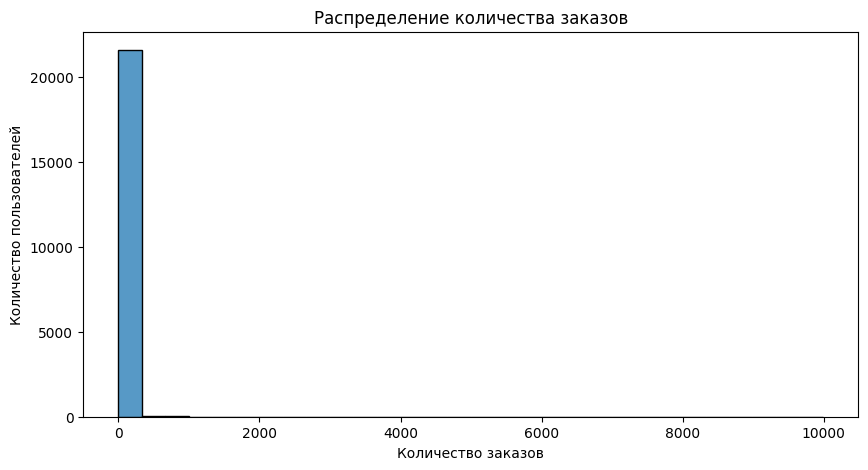

In [36]:
# распределение количества заказов

plt.figure(figsize=(10, 5))

sns.histplot(
    profiles['total_orders'],
    bins=30
)

plt.title(
    'Распределение количества заказов'
)

plt.xlabel(
    'Количество заказов'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

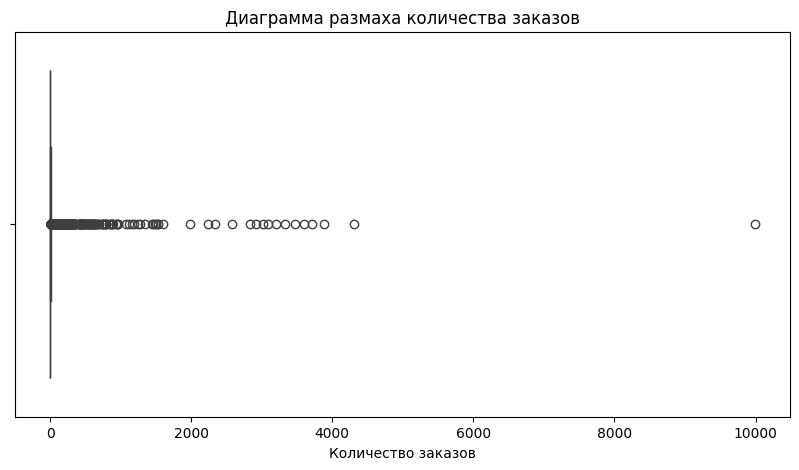

In [37]:
# диаграмма размаха количества заказов

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=profiles['total_orders']
)

plt.title(
    'Диаграмма размаха количества заказов'
)

plt.xlabel(
    'Количество заказов'
)

plt.show()

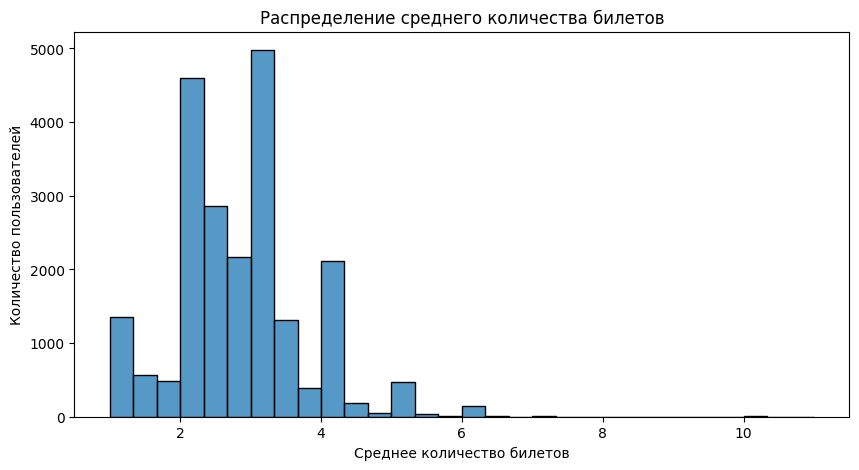

In [38]:
# распределение среднего количества билетов

plt.figure(figsize=(10, 5))

sns.histplot(
    profiles['avg_tickets_count'],
    bins=30
)

plt.title(
    'Распределение среднего количества билетов'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

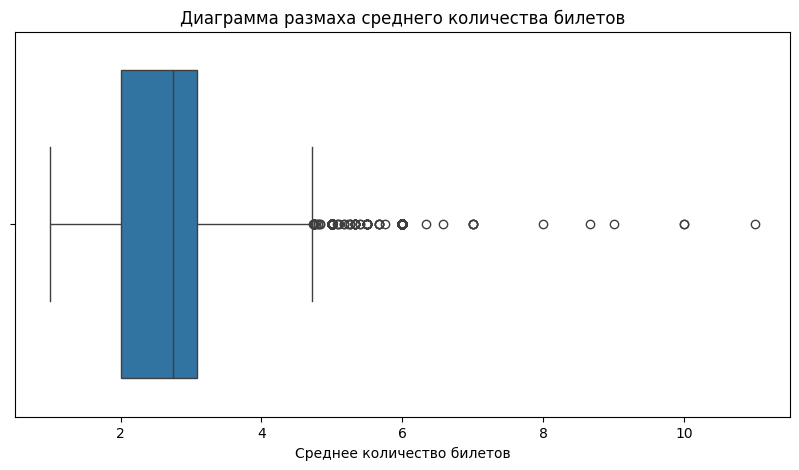

In [39]:
# диаграмма размаха среднего количества билетов

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=profiles['avg_tickets_count']
)

plt.title(
    'Диаграмма размаха среднего количества билетов'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.show()

In [40]:
# проверка аномальных значений по количеству заказов

profiles['total_orders'].quantile([0.95, 0.99])

0.95     31.0
0.99    151.0
Name: total_orders, dtype: float64

In [41]:
# проверка аномальных значений по количеству билетов

profiles['avg_tickets_count'].quantile([0.95, 0.99])

0.95    4.0
0.99    5.0
Name: avg_tickets_count, dtype: float64

In [42]:
# сохраняем размер датасета до фильтрации

profiles_before = len(profiles)

# фильтрация аномальных значений

orders_limit = profiles['total_orders'].quantile(0.99)

tickets_limit = (
    profiles['avg_tickets_count']
    .quantile(0.99)
)

profiles_filtered = profiles[
    (profiles['total_orders'] <= orders_limit)
    & (
        profiles['avg_tickets_count']
        <= tickets_limit
    )
]

# размер датасета после фильтрации

profiles_after = len(profiles_filtered)

filtered_share = (
    (profiles_before - profiles_after)
    / profiles_before
) * 100

print(
    'Количество пользователей до фильтрации:',
    profiles_before
)

print(
    'Количество пользователей после фильтрации:',
    profiles_after
)

print(
    'Доля удалённых пользователей: {:.2f}%'
    .format(filtered_share)
)

Количество пользователей до фильтрации: 21701
Количество пользователей после фильтрации: 21291
Доля удалённых пользователей: 1.89%


In [43]:
# статистика после фильтрации

profiles_filtered[
    [
        'total_orders',
        'avg_tickets_count',
        'avg_days_between_orders'
    ]
].describe()

,total_orders,avg_tickets_count,avg_days_between_orders
count,21291.000000,21291.000000,13174.0
mean,6.453948,2.716461,16.225342
std,14.073526,0.865853,22.483948
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.422155
50%,2.000000,2.750000,8.466667
75%,5.000000,3.040833,21.0
max,151.000000,5.000000,148.0


In [44]:
# обновляем основной датасет после фильтрации

profiles = profiles_filtered.copy()

## 12 Промежуточный вывод

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе были изучены основные характеристики пользовательских профилей.

Было рассчитано:

- общее количество пользователей в выборке;
- средняя выручка с заказа;
- доля пользователей с повторными заказами;
- доля пользователей с 5 и более заказами.

Также были исследованы распределения:

- количества заказов;
- среднего количества билетов;
- среднего времени между покупками.

Анализ показал, что большая часть пользователей совершает небольшое количество заказов. При этом в данных присутствуют аномальные значения.

Максимальное количество заказов на одного пользователя составило 9987, что значительно превышает основную массу наблюдений и может указывать на выбросы или особенности логирования данных.

Для снижения влияния выбросов была выполнена фильтрация по 99 перцентилю для признаков:

- `total_orders`;
- `avg_tickets_count`.

После фильтрации было удалено менее 2% пользователей, поэтому репрезентативность выборки сохранилась.

Очищенный датасет будет использоваться для дальнейшего исследовательского анализа и изучения факторов, влияющих на возврат пользователей.

</div>

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

Изучим характеристики первого заказа пользователей.

Проверим распределение пользователей:

- по типу первого мероприятия;
- по устройству первого заказа;
- по региону первого заказа;
- по билетному оператору первого заказа.

Для каждого сегмента рассчитаем:

- количество пользователей;
- долю пользователей в рамках признака.

Это позволит определить наиболее популярные точки входа пользователей на платформу и оценить равномерность распределения аудитории между сегментами.

</div>

In [45]:
# распределение пользователей по типу первого мероприятия

event_distribution = (
    profiles['first_event_type']
    .value_counts(normalize=False)
    .reset_index()
)

event_distribution.columns = [
    'event_type',
    'users_count'
]

event_distribution['share'] = (
    event_distribution['users_count']
    / event_distribution['users_count'].sum()
)

event_distribution

,event_type,users_count,share
0,концерты,9563,0.449157
1,другое,5141,0.241464
2,театр,4224,0.198394
3,стендап,1103,0.051806
4,спорт,750,0.035226
5,выставки,412,0.019351
6,ёлки,97,0.004556
7,фильм,1,0.000047


In [46]:
# распределение пользователей по устройству первого заказа

device_distribution = (
    profiles['first_device']
    .value_counts(normalize=False)
    .reset_index()
)

device_distribution.columns = [
    'device_type',
    'users_count'
]

device_distribution['share'] = (
    device_distribution['users_count']
    / device_distribution['users_count'].sum()
)

device_distribution

,device_type,users_count,share
0,mobile,17649,0.828942
1,desktop,3642,0.171058


In [47]:
# распределение пользователей по региону первого заказа

region_distribution = (
    profiles['first_region']
    .value_counts(normalize=False)
    .reset_index()
)

region_distribution.columns = [
    'region',
    'users_count'
]

region_distribution['share'] = (
    region_distribution['users_count']
    / region_distribution['users_count'].sum()
)

region_distribution.head(10)

,region,users_count,share
0,каменевский регион,6920,0.325020
1,североярская область,3732,0.175285
2,широковская область,1219,0.057254
3,озернинский край,674,0.031657
4,малиновоярский округ,523,0.024564
5,шанырский регион,465,0.021840
6,светополянский округ,459,0.021558
7,травяная область,458,0.021511
8,речиновская область,442,0.020760
9,яблоневская область,406,0.019069


In [48]:
# распределение пользователей по билетному оператору

service_distribution = (
    profiles['first_service']
    .value_counts(normalize=False)
    .reset_index()
)

service_distribution.columns = [
    'service_name',
    'users_count'
]

service_distribution['share'] = (
    service_distribution['users_count']
    / service_distribution['users_count'].sum()
)

service_distribution.head(10)

,service_name,users_count,share
0,билеты без проблем,4896,0.229956
1,мой билет,2974,0.139683
2,лови билет!,2780,0.130572
3,билеты в руки,2529,0.118783
4,облачко,2185,0.102626
5,весь в билетах,1280,0.060119
6,лучшие билеты,1172,0.055047
7,прачечная,582,0.027335
8,край билетов,458,0.021511
9,дом культуры,355,0.016674


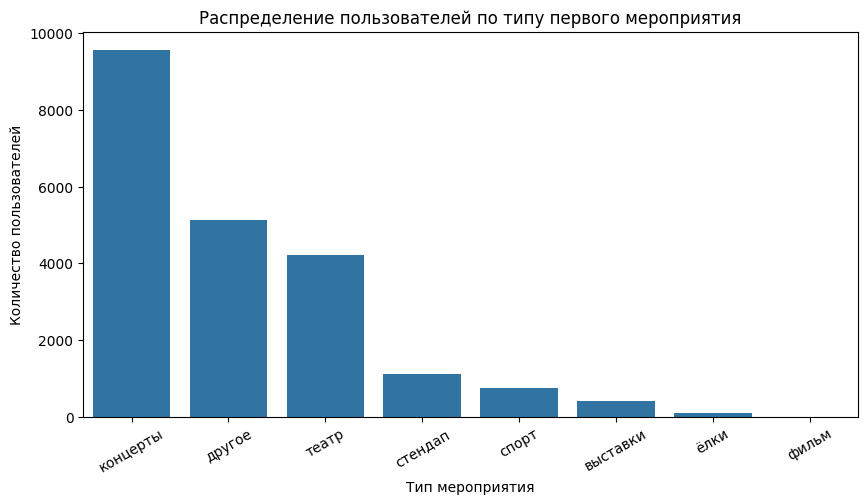

In [49]:
# визуализация распределения пользователей по типу мероприятия

plt.figure(figsize=(10, 5))

sns.barplot(
    data=event_distribution,
    x='event_type',
    y='users_count'
)

plt.title(
    'Распределение пользователей по типу первого мероприятия'
)

plt.xlabel(
    'Тип мероприятия'
)

plt.ylabel(
    'Количество пользователей'
)

plt.xticks(rotation=30)

plt.show()

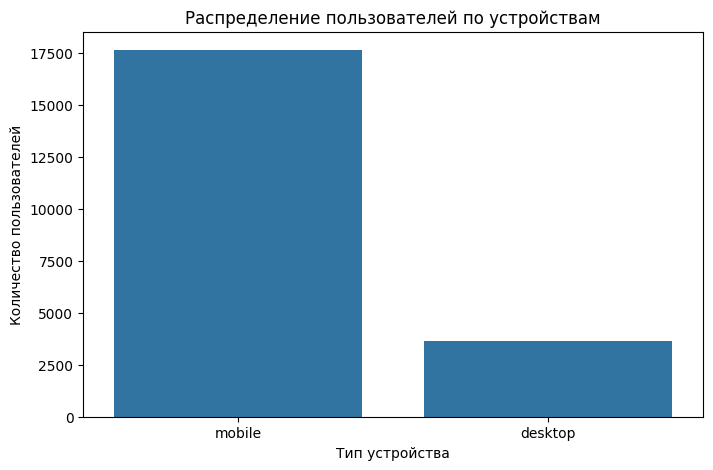

In [50]:
# визуализация распределения пользователей по устройствам

plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_distribution,
    x='device_type',
    y='users_count'
)

plt.title(
    'Распределение пользователей по устройствам'
)

plt.xlabel(
    'Тип устройства'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

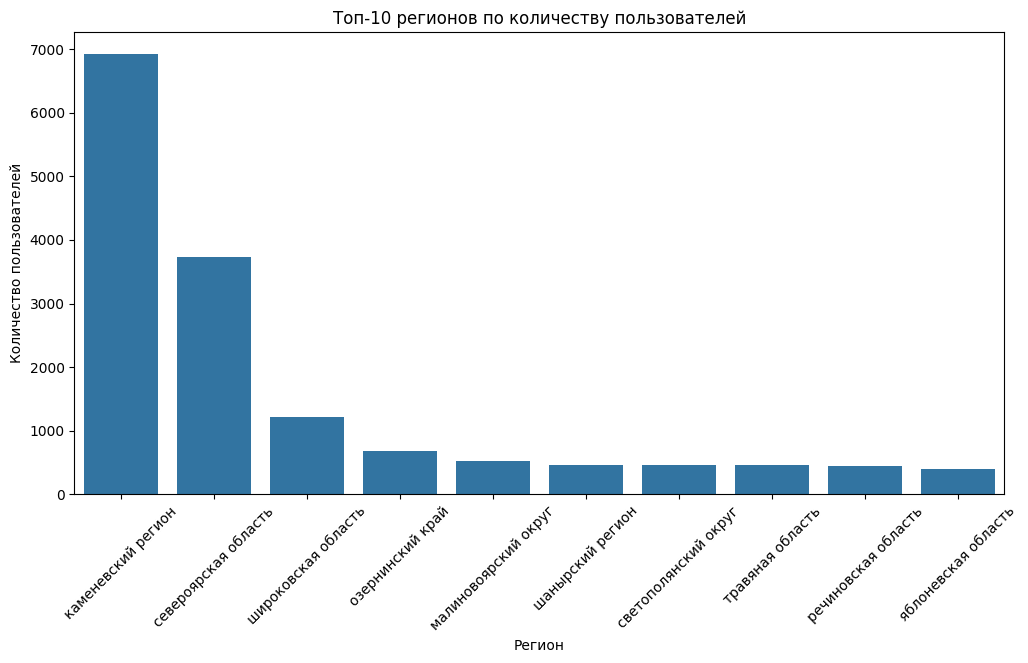

In [51]:
# визуализация распределения пользователей по регионам

plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_distribution.head(10),
    x='region',
    y='users_count'
)

plt.title(
    'Топ-10 регионов по количеству пользователей'
)

plt.xlabel(
    'Регион'
)

plt.ylabel(
    'Количество пользователей'
)

plt.xticks(rotation=45)

plt.show()

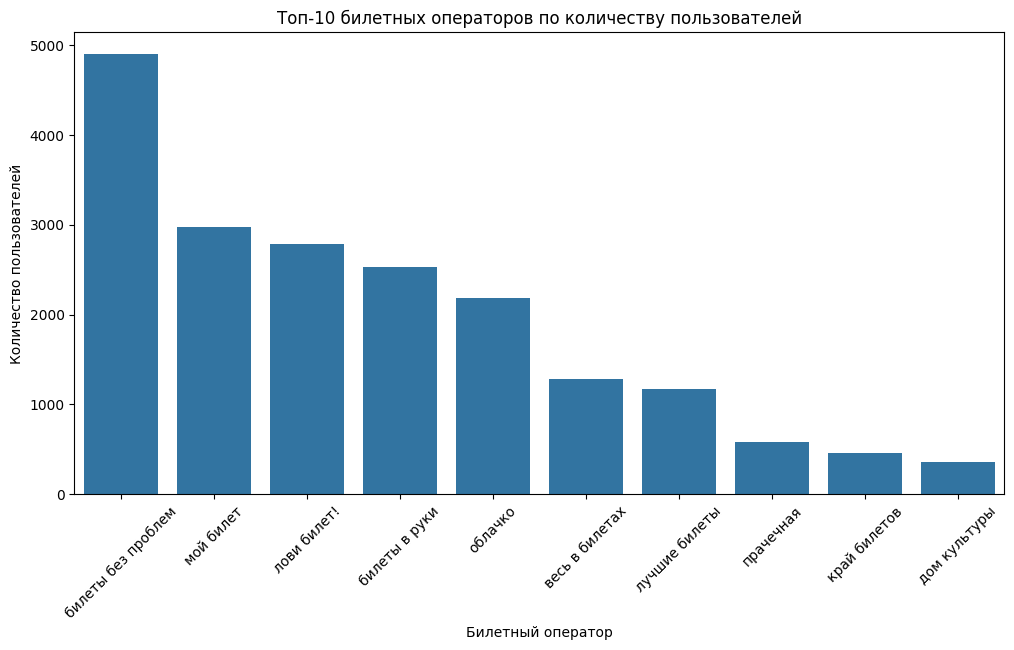

In [52]:
# визуализация распределения пользователей по билетным операторам

plt.figure(figsize=(12, 6))

sns.barplot(
    data=service_distribution.head(10),
    x='service_name',
    y='users_count'
)

plt.title(
    'Топ-10 билетных операторов по количеству пользователей'
)

plt.xlabel(
    'Билетный оператор'
)

plt.ylabel(
    'Количество пользователей'
)

plt.xticks(rotation=45)

plt.show()

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

В ходе исследования были изучены основные сегменты пользователей по признакам первого заказа.

Было установлено распределение пользователей:

- по типу первого мероприятия;
- по типу устройства;
- по региону первого заказа;
- по билетному оператору.

Анализ показал, что распределение пользователей является неравномерным.

Наиболее выраженные точки входа наблюдаются:

- среди пользователей мобильных устройств;
- среди популярных жанров мероприятий;
- среди отдельных регионов;
- среди крупнейших билетных операторов.

Наибольшая доля пользователей пришла через мобильные устройства — более 80% аудитории платформы.

Среди типов мероприятий наиболее популярными оказались концерты, которые составляют почти половину всех первых заказов пользователей.

Также наблюдается концентрация пользователей в отдельных регионах и у нескольких крупнейших билетных операторов.

Это говорит о том, что определённые сегменты привлекают существенно большую долю аудитории платформы и потенциально сильнее влияют на повторное возвращение пользователей.

Полученные результаты будут использованы на следующих этапах исследования для анализа связи между характеристиками первого заказа и вероятностью повторных покупок.

</div>

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе исследуем, как признаки первого заказа связаны с вероятностью повторного возвращения пользователя на платформу.

Для каждого сегмента рассчитаем долю пользователей, совершивших 2 и более заказа.

Анализ проведём по следующим признакам:

- тип первого мероприятия;
- устройство первого заказа;
- регион первого заказа;
- билетный оператор первого заказа.

Полученные результаты позволят выявить наиболее успешные сегменты пользователей и определить потенциально эффективные точки входа на платформу.

</div>

In [53]:
# средняя доля возвратов по всей выборке

mean_return_rate = profiles['is_two'].mean()

print(
    'Средняя доля пользователей с повторными заказами: {:.2%}'
    .format(mean_return_rate)
)

Средняя доля пользователей с повторными заказами: 61.55%


In [54]:
# возвраты по типу первого мероприятия

event_returns = (
    profiles.groupby('first_event_type')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values(
        by='return_rate',
        ascending=False
    )
    .reset_index()
)

event_returns

,first_event_type,users_count,return_rate
0,выставки,412,0.643204
1,театр,4224,0.638258
2,концерты,9563,0.618739
3,стендап,1103,0.611967
4,другое,5141,0.599689
5,ёлки,97,0.567010
6,спорт,750,0.550667
7,фильм,1,0.000000


In [55]:
# возвраты по типу устройства

device_returns = (
    profiles.groupby('first_device')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values(
        by='return_rate',
        ascending=False
    )
    .reset_index()
)

device_returns

,first_device,users_count,return_rate
0,desktop,3642,0.638935
1,mobile,17649,0.610629


In [56]:
# возвраты по регионам

region_returns = (
    profiles.groupby('first_region')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values(
        by='users_count',
        ascending=False
    )
    .head(10)
    .reset_index()
)

region_returns

,first_region,users_count,return_rate
0,каменевский регион,6920,0.621387
1,североярская область,3732,0.643891
2,широковская область,1219,0.650533
3,озернинский край,674,0.554896
4,малиновоярский округ,523,0.556405
5,шанырский регион,465,0.694624
6,светополянский округ,459,0.657952
7,травяная область,458,0.617904
8,речиновская область,442,0.638009
9,яблоневская область,406,0.600985


In [57]:
# возвраты по билетным операторам

service_returns = (
    profiles.groupby('first_service')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values(
        by='users_count',
        ascending=False
    )
    .head(10)
    .reset_index()
)

service_returns

,first_service,users_count,return_rate
0,билеты без проблем,4896,0.602328
1,мой билет,2974,0.608608
2,лови билет!,2780,0.614029
3,билеты в руки,2529,0.631079
4,облачко,2185,0.614645
5,весь в билетах,1280,0.630469
6,лучшие билеты,1172,0.619454
7,прачечная,582,0.628866
8,край билетов,458,0.652838
9,дом культуры,355,0.653521


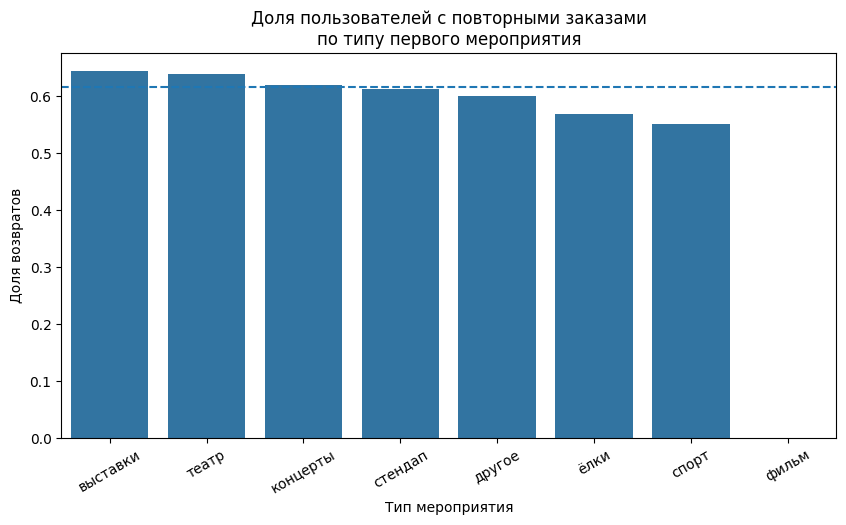

In [58]:
# визуализация возвратов по типу мероприятия

plt.figure(figsize=(10, 5))

sns.barplot(
    data=event_returns,
    x='first_event_type',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля пользователей с повторными заказами\nпо типу первого мероприятия'
)

plt.xlabel(
    'Тип мероприятия'
)

plt.ylabel(
    'Доля возвратов'
)

plt.xticks(rotation=30)

plt.show()

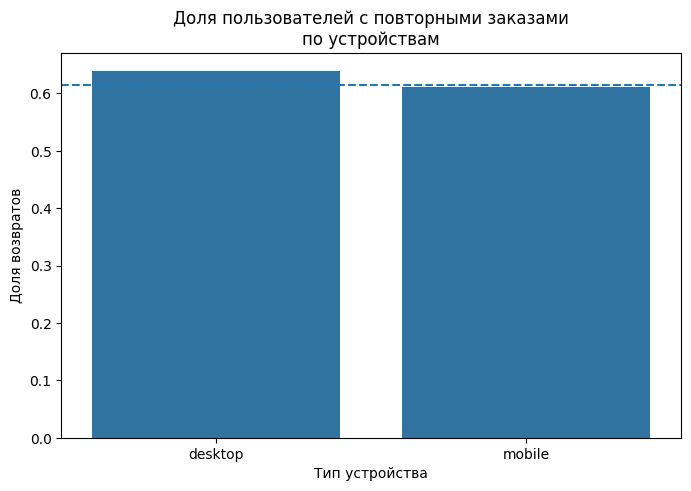

In [59]:
# визуализация возвратов по устройствам

plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_returns,
    x='first_device',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля пользователей с повторными заказами\nпо устройствам'
)

plt.xlabel(
    'Тип устройства'
)

plt.ylabel(
    'Доля возвратов'
)

plt.show()

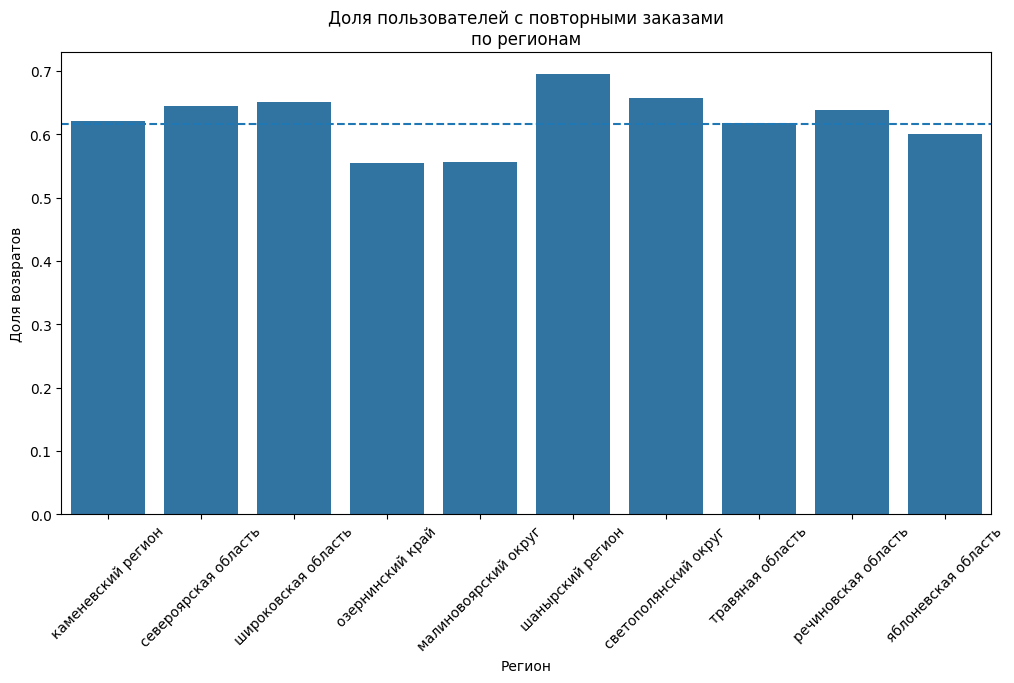

In [60]:
# визуализация возвратов по регионам

plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_returns,
    x='first_region',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля пользователей с повторными заказами\nпо регионам'
)

plt.xlabel(
    'Регион'
)

plt.ylabel(
    'Доля возвратов'
)

plt.xticks(rotation=45)

plt.show()

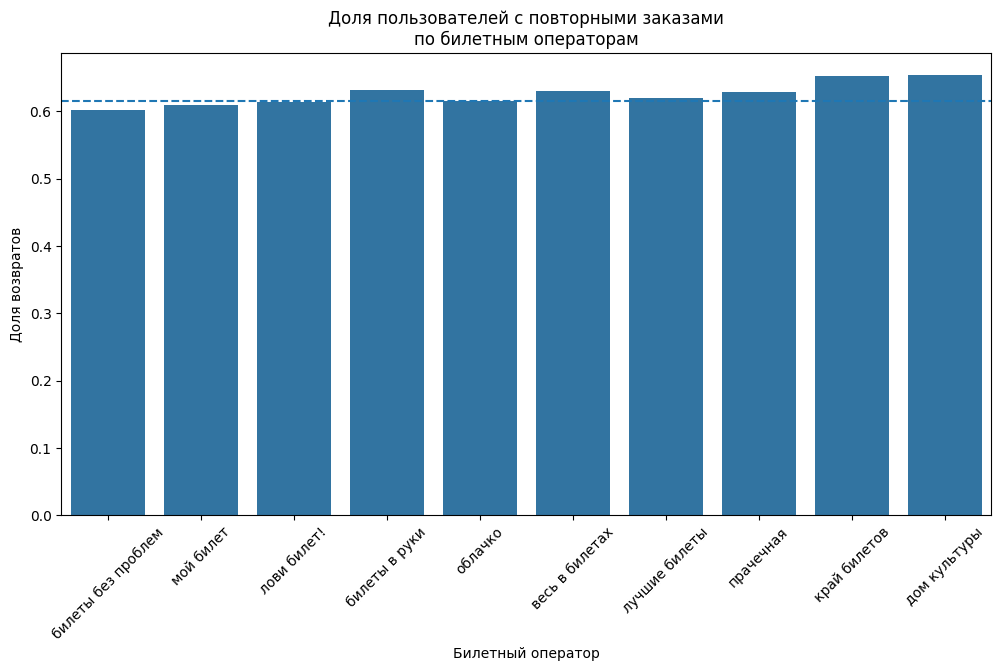

In [61]:
# визуализация возвратов по билетным операторам

plt.figure(figsize=(12, 6))

sns.barplot(
    data=service_returns,
    x='first_service',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля пользователей с повторными заказами\nпо билетным операторам'
)

plt.xlabel(
    'Билетный оператор'
)

plt.ylabel(
    'Доля возвратов'
)

plt.xticks(rotation=45)

plt.show()

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

В ходе анализа была исследована доля пользователей, совершивших повторный заказ, в различных сегментах аудитории.

Для каждого сегмента была рассчитана доля пользователей с 2 и более заказами.

Анализ показал, что вероятность повторного возвращения пользователей различается между сегментами.

Наиболее успешные точки входа наблюдаются:

- среди отдельных типов мероприятий;
- среди определённых регионов;
- среди крупнейших билетных операторов.

Некоторые сегменты демонстрируют долю возвратов выше средней по выборке, что может свидетельствовать о более высокой вовлечённости пользователей, пришедших через данные категории.

При этом необходимо учитывать размер сегментов: небольшие группы пользователей могут демонстрировать нестабильные значения долей возвратов.

Наиболее надёжными для интерпретации являются крупные сегменты с большим количеством пользователей.

Полученные результаты позволяют выделить потенциально наиболее эффективные каналы привлечения и сегменты пользователей с высокой вероятностью повторных покупок.

</div>

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

На данном этапе проверим продуктовые гипотезы, связанные с вероятностью повторного возвращения пользователей на платформу.

Проверка гипотез позволит определить, существуют ли сегменты пользователей, для которых вероятность повторного заказа выше среднего уровня.

Будут рассмотрены две гипотезы:

1. Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще пользователей, оформивших первый заказ на концерты.

2. В регионах с наибольшим количеством пользователей наблюдается более высокая доля повторных заказов по сравнению с менее активными регионами.

</div>

In [62]:
# сравнение возвратов пользователей спорта и концертов

event_hypothesis = (
    profiles[
        profiles['first_event_type']
        .isin(['спорт', 'концерты'])
    ]
    .groupby('first_event_type')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

event_hypothesis

,first_event_type,users_count,return_rate
0,концерты,9563,0.618739
1,спорт,750,0.550667


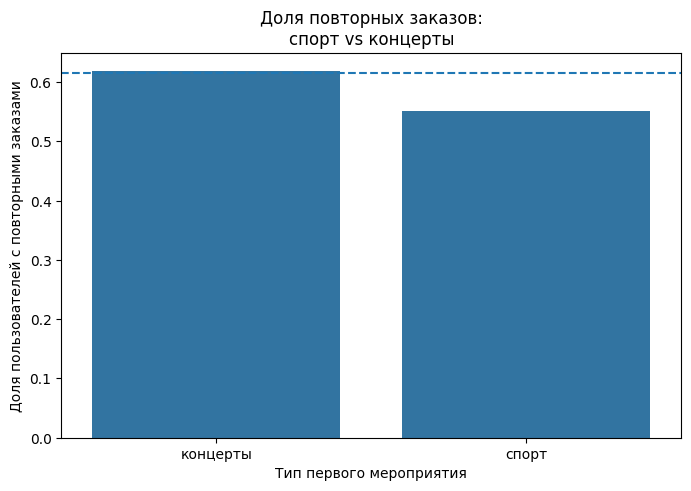

In [63]:
# визуализация гипотезы 1

plt.figure(figsize=(8, 5))

sns.barplot(
    data=event_hypothesis,
    x='first_event_type',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля повторных заказов:\nспорт vs концерты'
)

plt.xlabel(
    'Тип первого мероприятия'
)

plt.ylabel(
    'Доля пользователей с повторными заказами'
)

plt.show()

### Вывод по гипотезе 1
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

Анализ показал, что пользователи, совершившие первый заказ на концерты, возвращаются на платформу чаще пользователей, впервые оформивших заказ на спортивные мероприятия.

Доля повторных заказов среди пользователей концертов оказалась выше, чем среди пользователей спортивных мероприятий.

Следовательно, гипотеза о более высокой вероятности возврата пользователей спортивных мероприятий не подтвердилась.

</div>

In [64]:
# формируем таблицу по регионам

regions_analysis = (
    profiles.groupby('first_region')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values(
        by='users_count',
        ascending=False
    )
    .reset_index()
)

regions_analysis.head(10)

,first_region,users_count,return_rate
0,каменевский регион,6920,0.621387
1,североярская область,3732,0.643891
2,широковская область,1219,0.650533
3,озернинский край,674,0.554896
4,малиновоярский округ,523,0.556405
5,шанырский регион,465,0.694624
6,светополянский округ,459,0.657952
7,травяная область,458,0.617904
8,речиновская область,442,0.638009
9,яблоневская область,406,0.600985


In [65]:
# выделяем топ регионов по количеству пользователей

top_regions = regions_analysis.head(10)

# менее активные регионы

low_regions = regions_analysis.tail(10)

# средняя доля возвратов

top_return_rate = top_regions['return_rate'].mean()

low_return_rate = low_regions['return_rate'].mean()

print(
    'Средняя доля возвратов в популярных регионах: {:.2%}'
    .format(top_return_rate)
)

print(
    'Средняя доля возвратов в менее активных регионах: {:.2%}'
    .format(low_return_rate)
)

Средняя доля возвратов в популярных регионах: 62.37%
Средняя доля возвратов в менее активных регионах: 45.00%


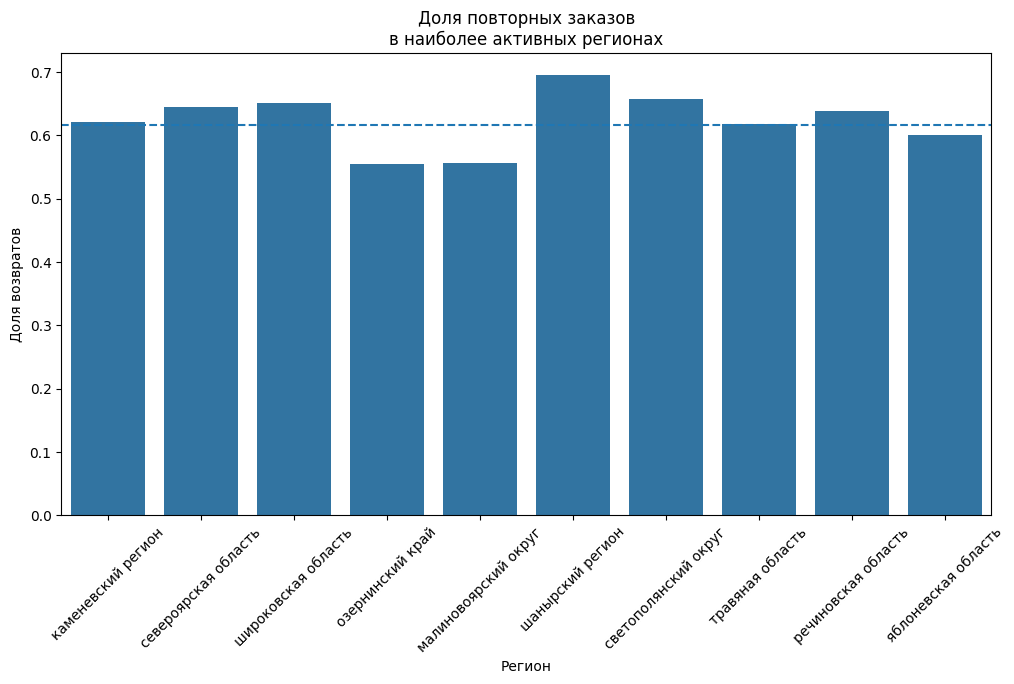

In [66]:
# визуализация возвратов по регионам

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_regions,
    x='first_region',
    y='return_rate'
)

plt.axhline(
    mean_return_rate,
    linestyle='--'
)

plt.title(
    'Доля повторных заказов\nв наиболее активных регионах'
)

plt.xlabel(
    'Регион'
)

plt.ylabel(
    'Доля возвратов'
)

plt.xticks(rotation=45)

plt.show()

### Вывод по гипотезе 2
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">

Проверка показала, что регионы с наибольшим количеством пользователей действительно демонстрируют высокие показатели повторных заказов.

Однако различия между регионами не являются одинаково выраженными для всех сегментов.

Часть наиболее активных регионов показывает долю возвратов выше среднего значения по выборке, что может свидетельствовать о более высокой вовлечённости пользователей.

При этом отдельные менее активные регионы также демонстрируют высокий уровень возвратов, поэтому связь между популярностью региона и вероятностью повторного заказа нельзя считать абсолютно линейной.

Таким образом, гипотеза подтверждается частично.

</div>

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [67]:
# пользователи с одним заказом

one_order_users = profiles[
    profiles['is_two'] == 0
]

# пользователи с повторными заказами

returned_users = profiles[
    profiles['is_two'] == 1
]

In [68]:
# статистика по средней выручке

one_order_users['avg_revenue_rub'].describe()

count    8187.000000
mean      549.228598
std       516.184834
min         0.070000
25%       138.875000
50%       384.720000
75%       833.890000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [69]:
# статистика по средней выручке вернувшихся пользователей

returned_users['avg_revenue_rub'].describe()

count    13104.000000
mean       550.146495
std        366.271807
min          0.352000
25%        278.398438
50%        503.006930
75%        750.588523
max       2628.421739
Name: avg_revenue_rub, dtype: float64

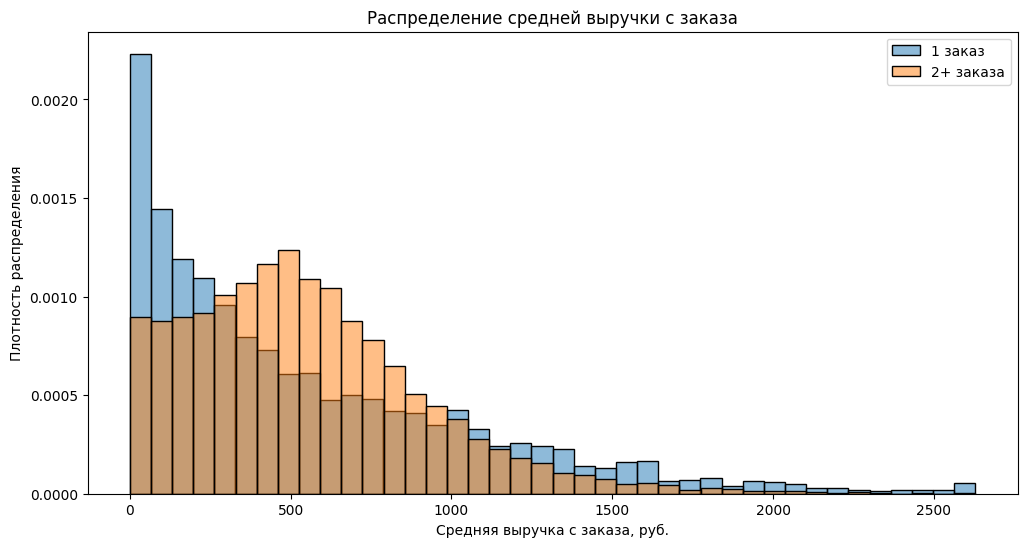

In [70]:
# сравнительная гистограмма распределения средней выручки

plt.figure(figsize=(12, 6))

sns.histplot(
    one_order_users['avg_revenue_rub'],
    bins=40,
    stat='density',
    alpha=0.5,
    label='1 заказ'
)

sns.histplot(
    returned_users['avg_revenue_rub'],
    bins=40,
    stat='density',
    alpha=0.5,
    label='2+ заказа'
)

plt.title(
    'Распределение средней выручки с заказа'
)

plt.xlabel(
    'Средняя выручка с заказа, руб.'
)

plt.ylabel(
    'Плотность распределения'
)

plt.legend()

plt.show()

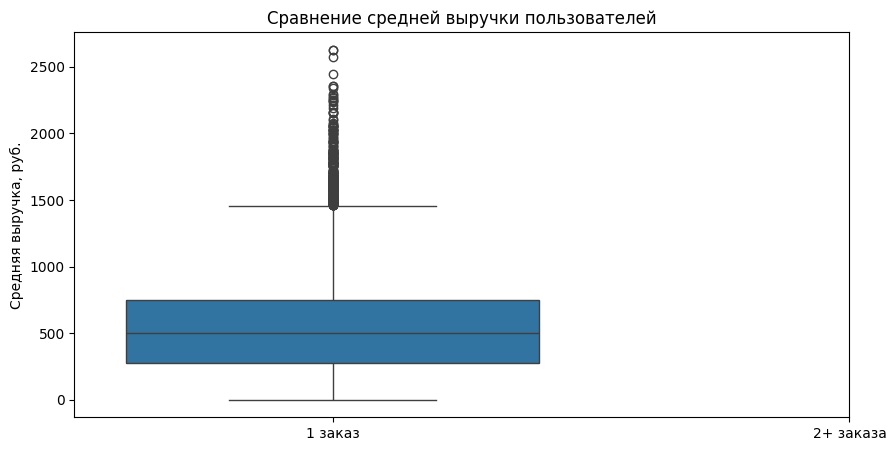

In [71]:
# диаграмма размаха средней выручки

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=[
        one_order_users['avg_revenue_rub'],
        returned_users['avg_revenue_rub']
    ]
)

plt.xticks(
    [0, 1],
    ['1 заказ', '2+ заказа']
)

plt.title(
    'Сравнение средней выручки пользователей'
)

plt.ylabel(
    'Средняя выручка, руб.'
)

plt.show()

## Промежуточный вывод

<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа было исследовано распределение средней выручки с заказа среди пользователей с одним заказом и пользователей, совершивших повторные покупки.

Анализ показал, что основная масса пользователей обеих групп концентрируется в диапазоне невысоких и средних значений выручки.

При этом распределение пользователей с повторными заказами оказалось немного смещено в сторону более высоких значений средней выручки.

Это может свидетельствовать о том, что пользователи с более дорогими заказами проявляют большую вовлечённость и чаще возвращаются на платформу.

Однако различия между группами нельзя назвать критически выраженными: значительная часть распределений пересекается.

Таким образом, средняя выручка с заказа может быть связана с вероятностью повторных покупок, но не является единственным фактором возврата пользователей.
</div>

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [72]:
# пользователи с 2–4 заказами

users_2_4 = profiles[
    (profiles['total_orders'] >= 2)
    & (profiles['total_orders'] <= 4)
]

# пользователи с 5 и более заказами

users_5_plus = profiles[
    profiles['total_orders'] >= 5
]

In [73]:
# статистика по средней выручке пользователей с 2–4 заказами

users_2_4['avg_revenue_rub'].describe()

count    7065.000000
mean      555.236453
std       416.705304
min         2.416667
25%       223.300000
50%       476.653333
75%       803.865000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [74]:
# статистика по средней выручке пользователей с 5+ заказами

users_5_plus['avg_revenue_rub'].describe()

count    6039.000000
mean      544.191775
std       296.501609
min         0.352000
25%       341.254806
50%       521.749000
75%       709.651814
max      2299.869022
Name: avg_revenue_rub, dtype: float64

In [75]:
# медианные значения выручки

print(
    'Медианная выручка пользователей с 2–4 заказами:',
    round(
        users_2_4['avg_revenue_rub'].median(),
        2
    )
)

print(
    'Медианная выручка пользователей с 5+ заказами:',
    round(
        users_5_plus['avg_revenue_rub'].median(),
        2
    )
)

Медианная выручка пользователей с 2–4 заказами: 476.65
Медианная выручка пользователей с 5+ заказами: 521.75


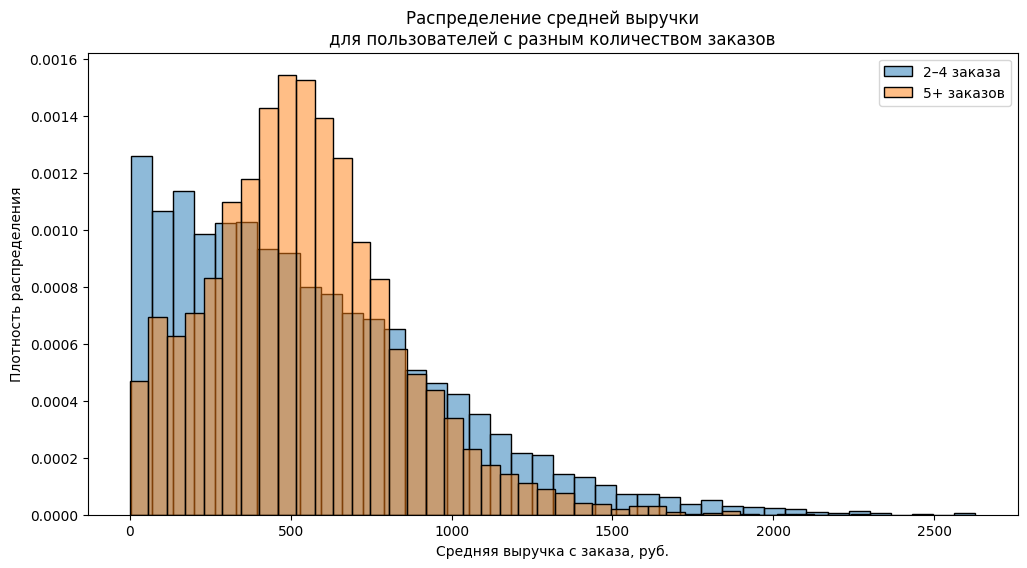

In [76]:
# сравнительная гистограмма распределения средней выручки

plt.figure(figsize=(12, 6))

sns.histplot(
    users_2_4['avg_revenue_rub'],
    bins=40,
    stat='density',
    alpha=0.5,
    label='2–4 заказа'
)

sns.histplot(
    users_5_plus['avg_revenue_rub'],
    bins=40,
    stat='density',
    alpha=0.5,
    label='5+ заказов'
)

plt.title(
    'Распределение средней выручки\nдля пользователей с разным количеством заказов'
)

plt.xlabel(
    'Средняя выручка с заказа, руб.'
)

plt.ylabel(
    'Плотность распределения'
)

plt.legend()

plt.show()

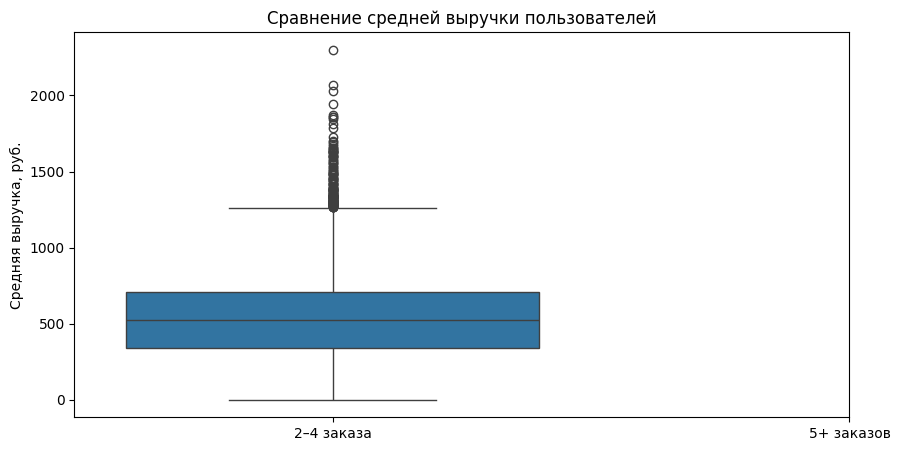

In [77]:
# диаграмма размаха

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=[
        users_2_4['avg_revenue_rub'],
        users_5_plus['avg_revenue_rub']
    ]
)

plt.xticks(
    [0, 1],
    ['2–4 заказа', '5+ заказов']
)

plt.title(
    'Сравнение средней выручки пользователей'
)

plt.ylabel(
    'Средняя выручка, руб.'
)

plt.show()

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа было проведено сравнение распределения средней выручки с заказа для пользователей с разной частотой покупок.

Анализ показал, что распределения двух групп во многом похожи, однако пользователи, совершившие 5 и более заказов, чаще демонстрируют более высокие значения средней выручки.

Медианная и средняя выручка у наиболее активных пользователей оказалась выше, чем у пользователей с 2–4 заказами.

Это может свидетельствовать о том, что более вовлечённые пользователи не только чаще совершают покупки, но и оформляют более дорогие заказы.

При этом различия между группами нельзя считать радикальными, поскольку значительная часть распределений пересекается.

Таким образом, наблюдается умеренная связь между активностью пользователя и средней выручкой с заказа.
</div>

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [78]:
# статистика по среднему количеству билетов

profiles['avg_tickets_count'].describe()

count    21291.000000
mean         2.716461
std          0.865853
min          1.000000
25%          2.000000
50%          2.750000
75%          3.040833
max          5.000000
Name: avg_tickets_count, dtype: float64

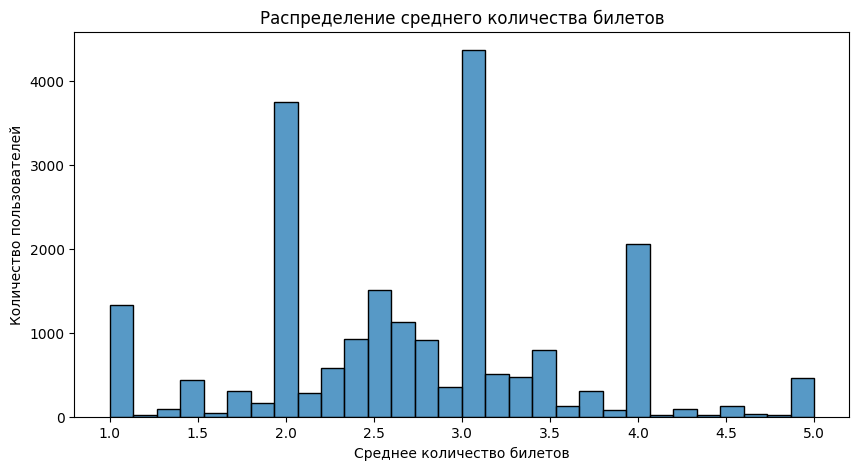

In [79]:
# распределение среднего количества билетов

plt.figure(figsize=(10, 5))

sns.histplot(
    profiles['avg_tickets_count'],
    bins=30
)

plt.title(
    'Распределение среднего количества билетов'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

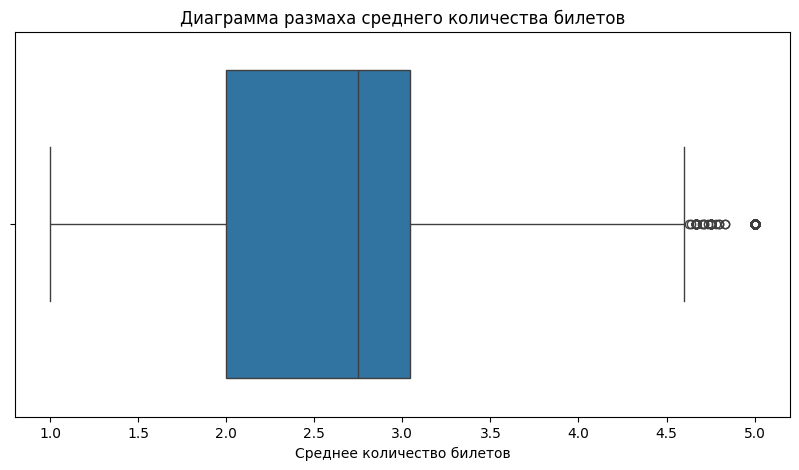

In [80]:
# диаграмма размаха

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=profiles['avg_tickets_count']
)

plt.title(
    'Диаграмма размаха среднего количества билетов'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.show()

In [81]:
# формирование сегментов пользователей

profiles['tickets_segment'] = pd.cut(
    profiles['avg_tickets_count'],
    bins=[0, 2, 3, 5, np.inf],
    labels=[
        '1–2 билета',
        '2–3 билета',
        '3–5 билетов',
        '5+ билетов'
    ],
    include_lowest=True
)

In [82]:
# анализ сегментов

tickets_analysis = (
    profiles.groupby('tickets_segment')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_analysis['share'] = (
    tickets_analysis['users_count']
    / tickets_analysis['users_count'].sum()
)

tickets_analysis

,tickets_segment,users_count,return_rate,share
0,1–2 билета,6110,0.400164,0.286976
1,2–3 билета,9834,0.742221,0.461885
2,3–5 билетов,5347,0.628390,0.251139


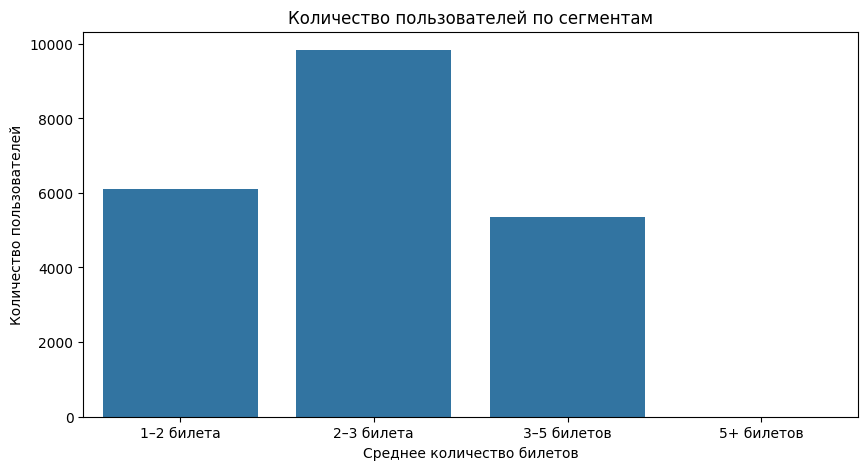

In [83]:
# визуализация количества пользователей

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tickets_analysis,
    x='tickets_segment',
    y='users_count'
)

plt.title(
    'Количество пользователей по сегментам'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.ylabel(
    'Количество пользователей'
)

plt.show()

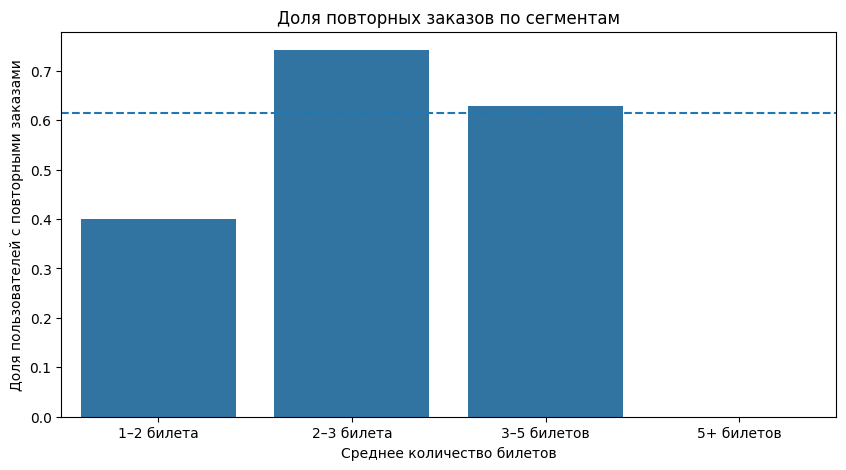

In [84]:
# визуализация доли повторных заказов

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tickets_analysis,
    x='tickets_segment',
    y='return_rate'
)

plt.axhline(
    profiles['is_two'].mean(),
    linestyle='--'
)

plt.title(
    'Доля повторных заказов по сегментам'
)

plt.xlabel(
    'Среднее количество билетов'
)

plt.ylabel(
    'Доля пользователей с повторными заказами'
)

plt.show()

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа было исследовано влияние среднего количества билетов в заказе на вероятность повторных покупок пользователей.

Анализ распределения показал, что основная масса пользователей сосредоточена в сегментах с небольшим количеством билетов — от 1 до 3 билетов в среднем на заказ.

Наиболее крупным оказался сегмент пользователей со средним количеством билетов от 2 до 3, тогда как сегмент от 3 до 5 билетов содержит существенно меньше наблюдений.

Сравнение долей повторных заказов показало, что вероятность возврата пользователей различается между сегментами.

Пользователи со средним количеством билетов от 2 до 5 демонстрируют более высокую долю повторных заказов по сравнению с пользователями, покупающими минимальное количество билетов.

После предварительной фильтрации выбросов значения среднего количества билетов более 5 отсутствуют, поэтому сегмент пользователей с 5 и более билетами оказался пустым и не участвовал в дальнейшем анализе.

Таким образом, наблюдается связь между средним количеством билетов в заказе и вероятностью повторной покупки: пользователи, приобретающие в среднем от 2 до 5 билетов, возвращаются на платформу чаще пользователей с минимальным количеством билетов.
</div>

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [85]:
# выделяем день недели первого заказа

profiles['first_order_weekday'] = (
    profiles['first_order_dt']
    .dt.day_name()
)

# порядок отображения дней недели

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# анализ пользователей по дням недели

weekday_analysis = (
    profiles.groupby('first_order_weekday')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

# доля пользователей

weekday_analysis['share'] = (
    weekday_analysis['users_count']
    / weekday_analysis['users_count'].sum()
)

weekday_analysis

,first_order_weekday,users_count,return_rate,share
0,Monday,2877,0.627737,0.135128
1,Tuesday,3127,0.619444,0.146870
2,Wednesday,3018,0.624586,0.141750
3,Thursday,3072,0.597005,0.144286
4,Friday,3204,0.602060,0.150486
5,Saturday,3264,0.630515,0.153304
6,Sunday,2729,0.606449,0.128176


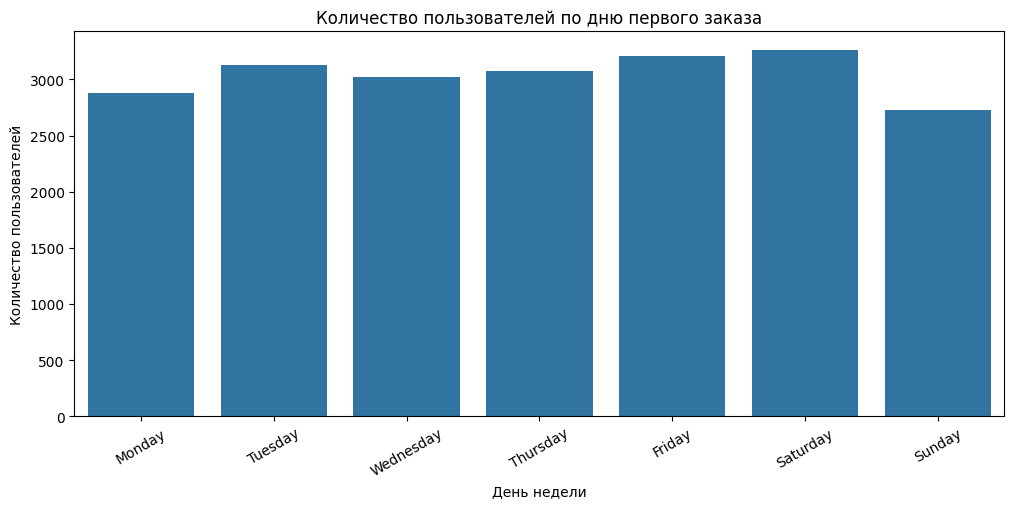

In [86]:
# визуализация количества пользователей по дням недели

plt.figure(figsize=(12, 5))

sns.barplot(
    data=weekday_analysis,
    x='first_order_weekday',
    y='users_count'
)

plt.title(
    'Количество пользователей по дню первого заказа'
)

plt.xlabel(
    'День недели'
)

plt.ylabel(
    'Количество пользователей'
)

plt.xticks(rotation=30)

plt.show()

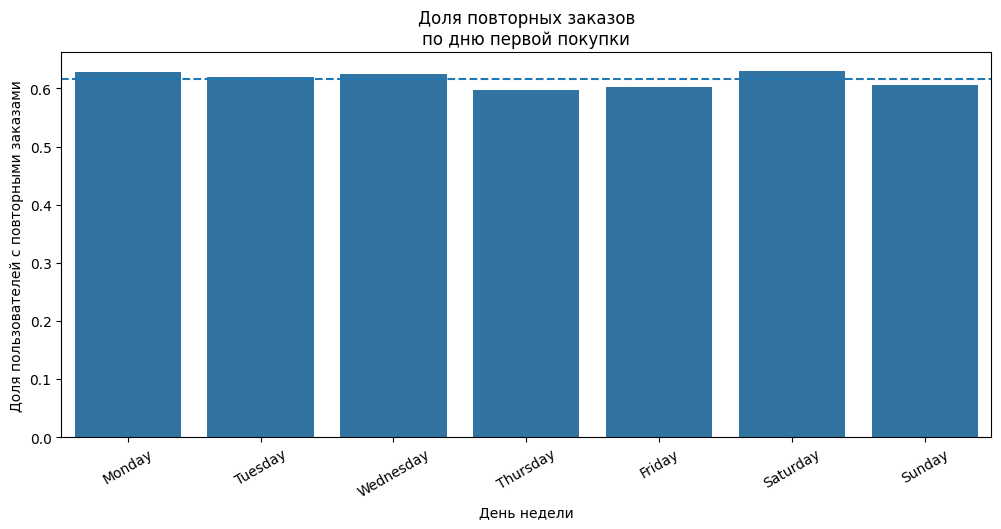

In [87]:
# визуализация доли повторных заказов

plt.figure(figsize=(12, 5))

sns.barplot(
    data=weekday_analysis,
    x='first_order_weekday',
    y='return_rate'
)

plt.axhline(
    profiles['is_two'].mean(),
    linestyle='--'
)

plt.title(
    'Доля повторных заказов\nпо дню первой покупки'
)

plt.xlabel(
    'День недели'
)

plt.ylabel(
    'Доля пользователей с повторными заказами'
)

plt.xticks(rotation=30)

plt.show()

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа было исследовано влияние дня недели первого заказа на вероятность повторного возвращения пользователей на платформу.

Для каждого дня недели были рассчитаны:

- количество пользователей;
- доля пользователей, совершивших повторные заказы.

Анализ показал, что распределение пользователей по дням недели является относительно равномерным, однако отдельные дни демонстрируют различия по доле повторных покупок.

При этом существенных аномалий или критически выраженных различий между днями недели обнаружено не было.

Это позволяет предположить, что день недели первого заказа оказывает ограниченное влияние на вероятность повторного возвращения пользователя на платформу.

Тем не менее отдельные дни могут демонстрировать немного более высокий уровень вовлечённости пользователей, что может быть полезно при планировании маркетинговых активностей и рекламных кампаний.
</div>

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [88]:
# пользователи с 2–4 заказами

users_2_4 = profiles[
    (profiles['total_orders'] >= 2)
    & (profiles['total_orders'] <= 4)
]

# пользователи с 5 и более заказами

users_5_plus = profiles[
    profiles['total_orders'] >= 5
]

In [89]:
# статистика среднего интервала между заказами
# для пользователей с 2–4 заказами

users_2_4[
    'avg_days_between_orders'
].describe()

count       7065.0
mean     21.348762
std      28.401957
min            0.0
25%            0.0
50%       9.333333
75%      33.666667
max          148.0
Name: avg_days_between_orders, dtype: Float64

In [90]:
# статистика среднего интервала между заказами
# для пользователей с 5+ заказами

users_5_plus[
    'avg_days_between_orders'
].describe()

count       6039.0
mean      9.900093
std       7.794449
min            0.0
25%       3.885714
50%       8.111111
75%      14.166667
max           37.5
Name: avg_days_between_orders, dtype: Float64

In [91]:
# медианные значения интервала между заказами

print(
    'Медианный интервал для пользователей с 2–4 заказами:',
    round(
        users_2_4[
            'avg_days_between_orders'
        ].median(),
        2
    )
)

print(
    'Медианный интервал для пользователей с 5+ заказами:',
    round(
        users_5_plus[
            'avg_days_between_orders'
        ].median(),
        2
    )
)

Медианный интервал для пользователей с 2–4 заказами: 9.33
Медианный интервал для пользователей с 5+ заказами: 8.11


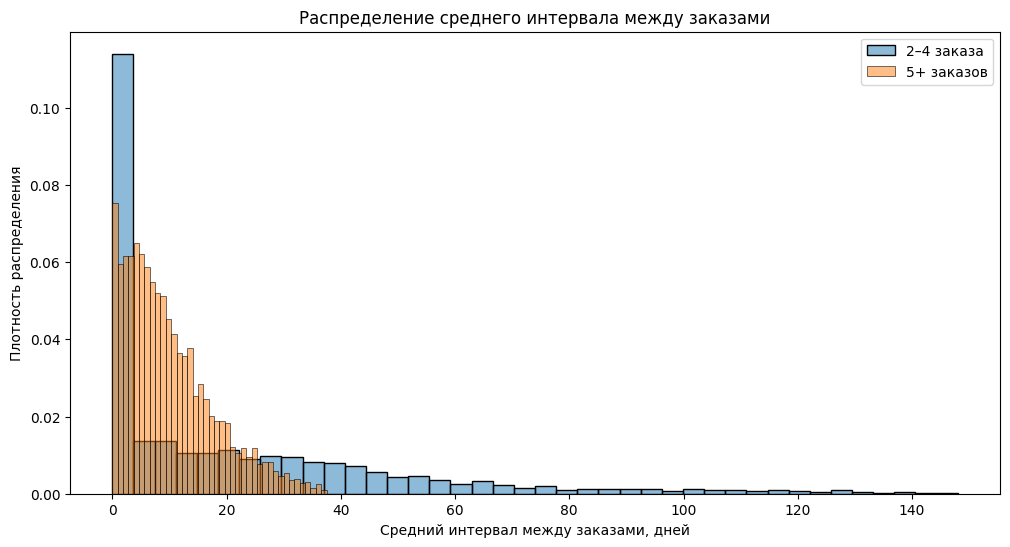

In [92]:
# сравнительная гистограмма распределения интервалов

plt.figure(figsize=(12, 6))

sns.histplot(
    users_2_4[
        'avg_days_between_orders'
    ].dropna(),
    bins=40,
    stat='density',
    alpha=0.5,
    label='2–4 заказа'
)

sns.histplot(
    users_5_plus[
        'avg_days_between_orders'
    ].dropna(),
    bins=40,
    stat='density',
    alpha=0.5,
    label='5+ заказов'
)

plt.title(
    'Распределение среднего интервала между заказами'
)

plt.xlabel(
    'Средний интервал между заказами, дней'
)

plt.ylabel(
    'Плотность распределения'
)

plt.legend()

plt.show()

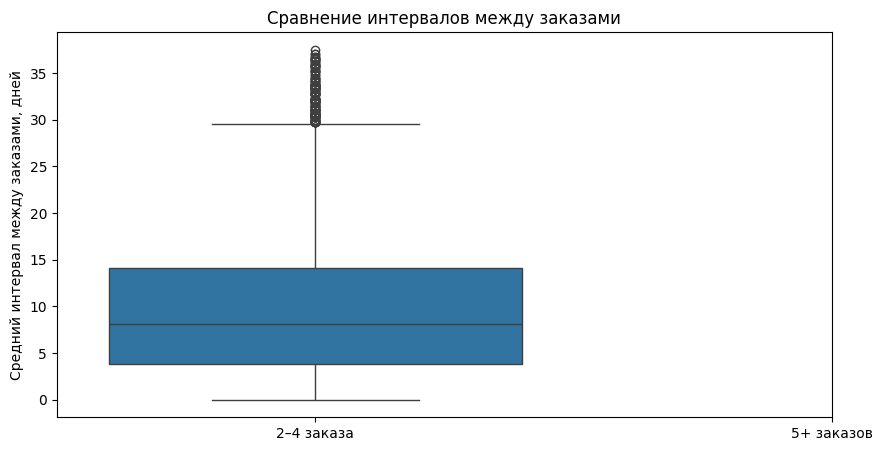

In [93]:
# диаграмма размаха

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=[
        users_2_4[
            'avg_days_between_orders'
        ].dropna(),

        users_5_plus[
            'avg_days_between_orders'
        ].dropna()
    ]
)

plt.xticks(
    [0, 1],
    ['2–4 заказа', '5+ заказов']
)

plt.title(
    'Сравнение интервалов между заказами'
)

plt.ylabel(
    'Средний интервал между заказами, дней'
)

plt.show()

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа было исследовано влияние среднего интервала между заказами на удержание пользователей платформы.

Было проведено сравнение двух групп пользователей:

- совершивших от 2 до 4 заказов;
- совершивших 5 и более заказов.

Анализ распределений показал, что пользователи с большим количеством заказов в среднем совершают покупки с меньшими временными интервалами между заказами.

При этом у пользователей с 2–4 заказами интервалы между покупками чаще оказываются более продолжительными и вариативными.

Полученные результаты позволяют предположить, что более короткий интервал между заказами связан с более высокой вовлечённостью пользователей и повышенной вероятностью долгосрочного удержания на платформе.

Таким образом, частота взаимодействия пользователей с сервисом может выступать одним из факторов, влияющих на вероятность повторных покупок и возврата пользователей.
</div>

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [94]:
# распределение количества заказов

profiles['total_orders'].value_counts().head(10)

total_orders
1     8187
2     3525
3     2155
4     1385
5      964
6      694
7      532
8      454
9      378
10     284
Name: count, dtype: int64

In [95]:
# создание сегментов по количеству заказов

profiles['orders_segment'] = pd.cut(
    profiles['total_orders'],
    bins=[0, 1, 4, np.inf],
    labels=[
        '1 заказ',
        '2–4 заказа',
        '5+ заказов'
    ]
)

In [96]:
# признаки для корреляционного анализа

corr_data = profiles[
    [
        'orders_segment',
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders',
        'first_order_weekday'
    ]
]

In [97]:
# расчёт корреляционной матрицы phi_k

phik_corr = corr_data.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders'
    ]
)

phik_corr

,orders_segment,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,first_order_weekday
orders_segment,1.000000,0.015939,0.126991,0.082694,0.044809,0.327301,0.647375,0.400606,0.030455
first_device,0.015939,1.000000,0.114409,0.083284,0.088219,0.078282,0.058370,0.022898,0.071814
first_region,0.126991,0.114409,1.000000,0.699185,0.502653,0.365017,0.141062,0.080463,0.159714
first_service,0.082694,0.083284,0.699185,1.000000,0.572354,0.377718,0.084828,0.053379,0.059511
first_event_type,0.044809,0.088219,0.502653,0.572354,1.000000,0.320054,0.093733,0.047876,0.054862
avg_revenue_rub,0.327301,0.078282,0.365017,0.377718,0.320054,1.000000,0.487007,0.088077,0.008473
avg_tickets_count,0.647375,0.058370,0.141062,0.084828,0.093733,0.487007,1.000000,0.169890,0.033767
avg_days_between_orders,0.400606,0.022898,0.080463,0.053379,0.047876,0.088077,0.169890,1.000000,0.000000
first_order_weekday,0.030455,0.071814,0.159714,0.059511,0.054862,0.008473,0.033767,0.000000,1.000000


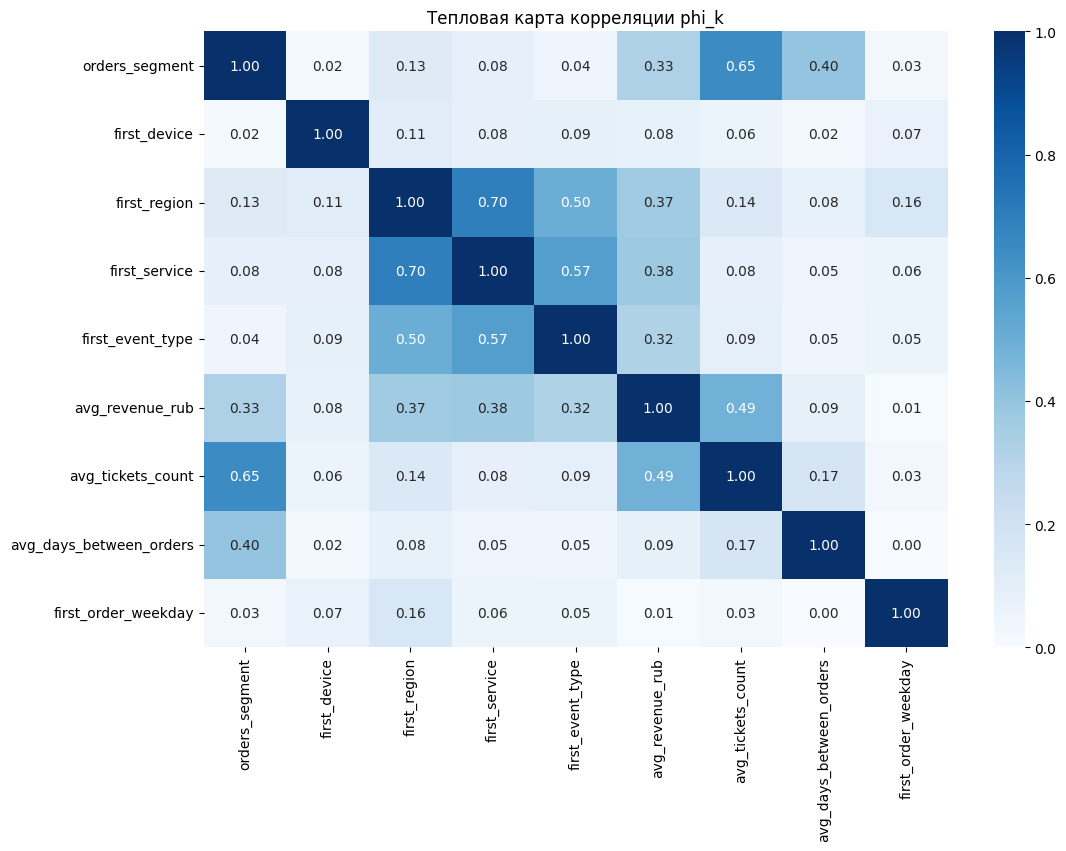

In [98]:
# визуализация тепловой карты корреляций

plt.figure(figsize=(12, 8))

sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title(
    'Тепловая карта корреляции phi_k'
)

plt.show()

In [99]:
# корреляция признаков с количеством заказов

phik_corr[
    'orders_segment'
].sort_values(ascending=False)

orders_segment             1.000000
avg_tickets_count          0.647375
avg_days_between_orders    0.400606
avg_revenue_rub            0.327301
first_region               0.126991
first_service              0.082694
first_event_type           0.044809
first_order_weekday        0.030455
first_device               0.015939
Name: orders_segment, dtype: float64

## Промежуточный вывод
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе анализа была исследована связь между признаками профиля пользователя и количеством совершённых заказов.

Для оценки зависимостей использовался коэффициент корреляции phi_k, позволяющий анализировать как числовые, так и категориальные признаки.

Поскольку распределение количества заказов оказалось неоднородным, пользователи были дополнительно разделены на сегменты:

- 1 заказ;
- от 2 до 4 заказов;
- 5 и более заказов.

Корреляционный анализ показал, что наибольшая связь с количеством заказов наблюдается у поведенческих признаков пользователей.

Наиболее заметная связь была выявлена для:

- среднего интервала между заказами;
- средней выручки с заказа;
- среднего количества билетов в заказе.

Категориальные признаки первого заказа, такие как устройство, регион или тип мероприятия, продемонстрировали значительно более слабую связь с количеством заказов пользователей.

Полученные результаты позволяют предположить, что поведение пользователей после первой покупки оказывает большее влияние на дальнейшую активность и удержание, чем характеристики первого заказа.
</div>

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.


# 19.1 Общий вывод и рекомендации
<div style="background-color:#d8ecff; padding:15px; border-radius:10px">
В ходе проекта был проведён анализ пользовательского поведения на платформе Яндекс Афиша с целью выявления факторов, влияющих на вероятность повторных покупок и удержание пользователей.

В исследовании использовались данные о заказах пользователей, характеристиках мероприятий, билетных операторах, устройствах и регионах проведения мероприятий. На этапе предобработки данные были очищены и подготовлены к анализу:

- выручка была приведена к единой валюте — российскому рублю;
- были обработаны пропуски и оптимизированы типы данных;
- выполнена проверка на дубликаты;
- проведена нормализация категориальных признаков;
- отфильтрованы выбросы по выручке и аномальные значения количества заказов и билетов.

После очистки данные сохранили репрезентативность: было удалено менее 3% заказов и менее 2% пользовательских профилей.

В итоговой выборке содержится 21 291 пользователь. Анализ показал, что большая часть пользователей совершает небольшое количество заказов, однако присутствует сегмент высокоактивных пользователей с большим числом покупок.

Средняя выручка с заказа составила около 552 рублей. Доля пользователей, совершивших повторные заказы, превысила 60%, а доля пользователей с 5 и более заказами составила около 29%.

Исследование признаков первого заказа показало, что пользователи распределены неравномерно. Основная часть аудитории приходит через мобильные устройства, а наиболее популярными типами мероприятий являются концерты и театральные события.

Наиболее успешные точки входа по возвратам наблюдались среди:
- пользователей театральных мероприятий и выставок;
- отдельных регионов с высокой вовлечённостью;
- некоторых билетных операторов.

При этом устройство первого заказа и день недели первой покупки показали слабую связь с вероятностью возврата пользователя.

Анализ средней выручки и состава заказа показал, что пользователи с более высокой средней выручкой и большим количеством билетов чаще совершают повторные покупки.

Наиболее высокая доля повторных заказов наблюдалась у пользователей со средним количеством билетов от 2 до 5.

Исследование временных характеристик показало, что пользователи с большим количеством заказов совершают покупки с меньшими интервалами между ними. Это свидетельствует о том, что высокая частота взаимодействия с платформой связана с более высоким удержанием пользователей.

Корреляционный анализ phi_k подтвердил, что наиболее сильная связь с количеством заказов наблюдается у поведенческих признаков пользователей:

- среднего количества билетов в заказе (phi_k = 0.65);
- среднего интервала между заказами (phi_k = 0.40);
- средней выручки с заказа (phi_k = 0.33).

Категориальные признаки первого заказа продемонстрировали значительно более слабую связь с количеством покупок.

## Рекомендации

По результатам анализа можно предложить следующие рекомендации:

1. Сфокусировать маркетинговые активности на пользователях с высокой вовлечённостью:
   - пользователях с 2–5 билетами в заказе;
   - пользователях с высокой средней выручкой;
   - пользователях, совершающих покупки с небольшими временными интервалами.

2. Усилить работу с наиболее успешными точками входа:
   - театральными мероприятиями;
   - концертами;
   - регионами с высокой долей возвратов;
   - билетными операторами с наиболее высокой вовлечённостью пользователей.

3. Разработать механики удержания для пользователей с одним заказом:
   - персональные рекомендации;
   - скидки на повторную покупку;
   - email- и push-кампании после первого заказа.

4. Использовать поведенческие признаки пользователей при построении модели прогнозирования возврата, поскольку именно они показали наиболее сильную связь с количеством покупок.

В целом результаты исследования показывают, что удержание пользователей в большей степени определяется их дальнейшим поведением после первой покупки, чем характеристиками самого первого заказа.

</div>

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**